# Assignment 3 — Question 2

Here I plot the degree correlations of the real-world network using the knn vs k plot, and compare it against a random graph baseline averaged over 100 instances. This tells me whether high-degree nodes tend to connect to other high-degree nodes (assortative) or to low-degree nodes (disassortative).

**Note on data:** The dataset (Email-EU-core) is reused from `Question 1/` automatically. If it is not found there, the notebook will attempt to download it directly. If the download fails, manually download the file from https://snap.stanford.edu/data/email-Eu-core.txt.gz and place it in either the `Question 1/` or `Question 2/` folder.

In [6]:
import os
import gzip
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

random.seed(42)
np.random.seed(42)

# Resolve this notebook's directory so all files are saved alongside it
try:
    SAVE_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    SAVE_DIR = os.path.abspath(os.path.dirname(''))
print(f'Save directory: {SAVE_DIR}')

Save directory: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 2


## Dataset

Same Email-EU-core network from Q1, loaded as undirected — 986 nodes, 16,064 edges (from SNAP). Using the same dataset to keep the analysis consistent across questions.

In [7]:
Q1_DATA    = os.path.join(os.path.dirname(SAVE_DIR), 'Question 1', 'email-Eu-core.txt.gz')
LOCAL_DATA = os.path.join(SAVE_DIR, 'email-Eu-core.txt.gz')
DATA_URL   = 'https://snap.stanford.edu/data/email-Eu-core.txt.gz'

if os.path.exists(Q1_DATA):
    data_path = Q1_DATA
    print(f'Using dataset from Question 1.')
elif os.path.exists(LOCAL_DATA):
    data_path = LOCAL_DATA
    print('Using local dataset.')
else:
    print('Downloading email-Eu-core dataset...')
    urllib.request.urlretrieve(DATA_URL, LOCAL_DATA)
    data_path = LOCAL_DATA
    print('Download complete.')

G_real = nx.Graph()
with gzip.open(data_path, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        u, v = map(int, line.split())
        if u != v:
            G_real.add_edge(u, v)

print(f'Nodes: {G_real.number_of_nodes()}, Edges: {G_real.number_of_edges()}')

Using dataset from Question 1.
Nodes: 986, Edges: 16064


## Computing knn(k)

For each node I compute its average nearest-neighbour degree — the mean degree of all its direct neighbours. Then I group nodes by their degree k and average their knn values to get knn(k).

- knn(k) increasing with k → assortative (hubs tend to connect to other hubs)
- knn(k) decreasing with k → disassortative (hubs tend to connect to low-degree nodes)

In [8]:
def compute_knn_by_k(G):
    """Compute knn(k): average nearest-neighbour degree binned by degree k."""
    degrees = dict(G.degree())
    knn_by_k = defaultdict(list)

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        ki = degrees[node]
        if ki == 0:
            continue
        knn_i = np.mean([degrees[n] for n in neighbors])
        knn_by_k[ki].append(knn_i)

    k_sorted = sorted(knn_by_k.keys())
    knn_avg  = [np.mean(knn_by_k[k]) for k in k_sorted]
    return np.array(k_sorted), np.array(knn_avg)


k_real, knn_real = compute_knn_by_k(G_real)
print(f'Degree range: {k_real.min()} – {k_real.max()}')

# Pearson assortativity coefficient as a summary statistic
r = nx.degree_assortativity_coefficient(G_real)
print(f'Pearson assortativity coefficient r = {r:.4f}')

Degree range: 1 – 345
Pearson assortativity coefficient r = -0.0257


## Random Graph Baseline — 100 Instances

I generate 100 Configuration Model instances with the same degree sequence and compute knn(k) for each, then average. This gives the expected knn vs k for a network with no degree correlations beyond what's forced by the degree sequence.

In [9]:
def configuration_model(degree_seq):
    """Configuration Model: preserve degree sequence by randomly pairing stubs."""
    stubs = []
    for node, deg in enumerate(degree_seq):
        stubs.extend([node] * deg)
    if len(stubs) % 2 != 0:
        stubs.pop()
    random.shuffle(stubs)

    G = nx.Graph()
    G.add_nodes_from(range(len(degree_seq)))
    for i in range(0, len(stubs) - 1, 2):
        u, v = stubs[i], stubs[i + 1]
        if u != v:
            G.add_edge(u, v)
    return G


N_INSTANCES = 100
orig_degree_seq = [d for _, d in G_real.degree()]

# Collect knn values per degree k across all instances
rand_knn_by_k = defaultdict(list)

print(f'Generating {N_INSTANCES} Configuration Model instances...')
for i in range(N_INSTANCES):
    if (i + 1) % 10 == 0:
        print(f'  Instance {i+1}/{N_INSTANCES}')
    G_rand = configuration_model(orig_degree_seq)
    k_arr, knn_arr = compute_knn_by_k(G_rand)
    for k_val, knn_val in zip(k_arr, knn_arr):
        rand_knn_by_k[k_val].append(knn_val)

print('Done.')

k_rand = sorted(rand_knn_by_k.keys())
knn_rand_mean = np.array([np.mean(rand_knn_by_k[k]) for k in k_rand])
knn_rand_std  = np.array([np.std(rand_knn_by_k[k])  for k in k_rand])

Generating 100 Configuration Model instances...
  Instance 10/100
  Instance 20/100
  Instance 30/100
  Instance 40/100
  Instance 50/100
  Instance 60/100
  Instance 70/100
  Instance 80/100
  Instance 90/100
  Instance 100/100
Done.


## knn vs k Plot

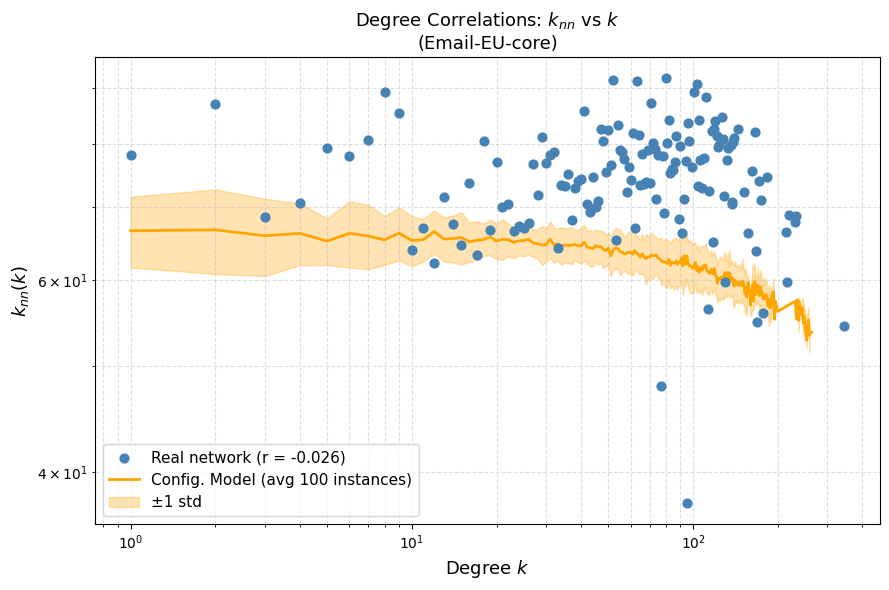

Saved: /Users/shamiksinha/Desktop/CSE655_Network-Science/Assignment3/Question 2/knn_vs_k.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

# Real network
ax.scatter(k_real, knn_real, color='steelblue', s=40, zorder=5,
           label=f'Real network (r = {r:.3f})')

# Random (Config. Model) average ± std
ax.plot(k_rand, knn_rand_mean, color='orange', linewidth=2,
        label='Config. Model (avg 100 instances)')
ax.fill_between(k_rand,
                knn_rand_mean - knn_rand_std,
                knn_rand_mean + knn_rand_std,
                color='orange', alpha=0.3, label='±1 std')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=13)
ax.set_ylabel('$k_{nn}(k)$', fontsize=13)
ax.set_title('Degree Correlations: $k_{nn}$ vs $k$\n(Email-EU-core)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'knn_vs_k.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## Observations

The Pearson assortativity coefficient r gives a quick single-number summary — negative means disassortative, positive means assortative.

For the Email-EU-core network, r = -0.0257, which is very close to zero — so the network is essentially uncorrelated. The knn(k) curve is mostly flat with some scatter at high k, consistent with this near-zero assortativity.

The random graph baseline is also flat, as expected. Both curves are close to each other, which tells us that most of the degree correlation structure (or lack of it) is already explained by the degree sequence alone. Any deviations at the high-degree tail are mainly due to the small number of high-degree nodes making estimates noisy.